# THEMIS-A 電子pitch angleのplot
[50, 300] eV, [300, 1000] eV, [1, 5] keVの、各22.5度ずつのデータ

In [23]:
import numpy as np
import pandas as pd
import xarray as xr
import pytplot as pt
from pathlib import Path

pt.del_data('*')

dir_name = f'/mnt/j/observation_data/THEMIS_A_from_Artemyev'
file_name_ePA_1 = f'{dir_name}/2022-09-01_koseki_a_peef_PAD_22-23.dat'
file_name_ePA_2 = f'{dir_name}/2022-09-01_koseki_a_peef_PAD_23-24.dat'

def load_electron_flux(fname: str,
                       bands=('[30,300]', '[300,1000]', '[1000,5000]'),
                       n_lines_per_block: int = 5) -> xr.DataArray:
    """
    THEMIS ESA ASCII ファイル → electron_flux DataArray へ変換
    ----------------------------------
    dims  : time × band × pitch
    coords: time (datetime64[ns])
            band (str)
            pitch (deg)
    """
    lines = [ln.rstrip() for ln in Path(fname).read_text().splitlines() if ln.strip()]
    if len(lines) % n_lines_per_block != 0:
        raise ValueError('行数がブロック長の倍数になっていません')

    times, flux_blocks = [], []
    for i in range(0, len(lines), n_lines_per_block):
        # 時刻
        times.append(np.datetime64(lines[i].replace('/', 'T'), 'ns'))
        # pitch 角（全ブロック同一前提）
        if i == 0:
            pitch = np.fromstring(lines[i + 1], sep=' ')
        # フラックス
        block = [np.fromstring(lines[i + 2 + k], sep=' ') for k in range(len(bands))]
        flux_blocks.append(np.stack(block))          # (n_band, n_pitch)

    flux = np.stack(flux_blocks)                     # (Nt, n_band, n_pitch)

    da = xr.DataArray(
        flux,
        dims=('time', 'band', 'pitch'),
        coords=dict(
            time  = ('time',  np.asarray(times)),
            band  = ('band',  np.asarray(bands, dtype='U')),
            pitch = ('pitch', pitch)
        ),
        name='electron_flux'
    )
    return da

ds_ePA_1 = load_electron_flux(file_name_ePA_1)
ds_ePA_2 = load_electron_flux(file_name_ePA_2)

ds_ePA_1 = ds_ePA_1.drop_duplicates(dim='time')
ds_ePA_2 = ds_ePA_2.drop_duplicates(dim='time')
ds_ePA   = xr.concat([ds_ePA_1, ds_ePA_2], dim='time').sortby('time')

ds_ePA

<xarray.DataArray 'electron_flux' (time: 1943, band: 3, pitch: 8)> Size: 373kB
array([[[          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan]],

       [[3.1881885e+04, 5.2907828e+04, 5.5339770e+04, ...,
         5.4493871e+04, 5.1219914e+04, 3.1580879e+04],
        [5.9787571e+01, 2.2215686e+02, 1.5787891e+02, ...,
         2.4326497e+02, 1.5249895e+02, 2.2278484e+01],
        [2.6512350e+02, 4.4128894e+02, 5.8913623e+02, ...,
         5.9301062e+02, 4.8949951e+02, 2.8510403e+02]],

       [[3.6420488e+04, 5.3730816e+04, 5.5682816e+04, ...,
         4.8877906e+04, 5.1392523e+04, 3.2985746e+04],
        [2.5906086e+01, 1.2748460e+02, 2.3176497e+02, ...,
         9.1758476e+01, 1.9442441e+02, 0.0000000e+00],
        [2.8032248e+02, 4.4477576e+02, 6.2515125e+02, ...,
         6.3520074e+02, 4.7891629e+02, 2.2436491e+02]],
...
         2.9693660e+03, 2.9643501e+03, 3.7798052e+03],
        [9.3215645e+03, 1.0423633e+04, 1.0955101e+04, ...,
         1.0770447e+04, 1.1078390e+04, 1.0131428e+04],
        [9.7850391e+03, 1.2841054e+04, 1.4258858e+04, ...,
         1.4398737e+04, 1.3197991e+04, 1.0219436e+04]],

       [[3.0691865e+03, 3.1058027e+03, 2.7417332e+03, ...,
         2.6851960e+03, 2.7662512e+03, 3.8460225e+03],
        [1.0123703e+04, 1.0078020e+04, 1.0533284e+04, ...,
         1.1144177e+04, 1.1329320e+04, 1.0200856e+04],
        [9.9762412e+03, 1.3230148e+04, 1.4447503e+04, ...,
         1.4515578e+04, 1.3565608e+04, 1.0120892e+04]],

       [[2.6088494e+03, 2.9831323e+03, 3.1105439e+03, ...,
         3.0989285e+03, 3.0322417e+03, 4.1975630e+03],
        [1.0256245e+04, 1.1288203e+04, 1.1533946e+04, ...,
         1.1417331e+04, 1.0968505e+04, 1.0135178e+04],
        [1.0267690e+04, 1.3175204e+04, 1.4185102e+04, ...,
         1.4198084e+04, 1.3375251e+04, 1.0495383e+04]]],
      shape=(1943, 3, 8))
Coordinates:
  * time     (time) datetime64[ns] 16kB 2022-09-01T22:00:01 ... 2022-09-01T23...
  * band     (band) <U11 132B '[30,300]' '[300,1000]' '[1000,5000]'
  * pitch    (pitch) float64 64B 11.25 33.75 56.25 78.75 101.2 123.8 146.2 168.8

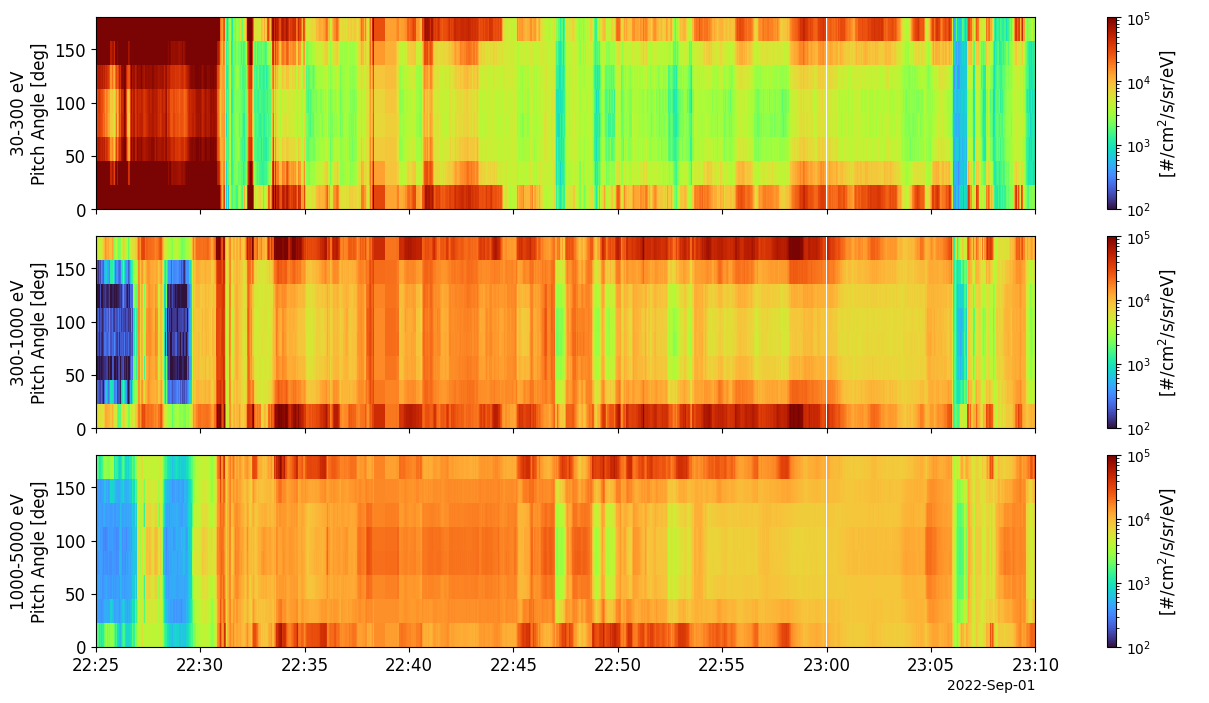

In [39]:
import pytplot as pt

pt.store_data(
    'THEMIS_A_electron_flux_30-300eV',
    data={
        'x': ds_ePA.time,
        'y': ds_ePA.sel(band='[30,300]').values,
        'v': ds_ePA.pitch.values.tolist()
    },
    attr_dict={
        'ytitle': '30-300 eV',
    }
)
pt.store_data(
    'THEMIS_A_electron_flux_300-1000eV',
    data={
        'x': ds_ePA.time,
        'y': ds_ePA.sel(band='[300,1000]').values,
        'v': ds_ePA.pitch.values.tolist()
    },
    attr_dict={
        'ytitle': '300-1000 eV',
    }
)
pt.store_data(
    'THEMIS_A_electron_flux_1000-5000eV',
    data={
        'x': ds_ePA.time,
        'y': ds_ePA.sel(band='[1000,5000]').values,
        'v': ds_ePA.pitch.values.tolist()
    },
    attr_dict={
        'ytitle': '1000-5000 eV',
    }
)

var_list = [
    'THEMIS_A_electron_flux_30-300eV',
    'THEMIS_A_electron_flux_300-1000eV',
    'THEMIS_A_electron_flux_1000-5000eV'
]

pt.options('THEMIS_A_electron_flux_30-300eV', 'ytitle', '30-300 eV')
pt.options('THEMIS_A_electron_flux_300-1000eV', 'ytitle', '300-1000 eV')
pt.options('THEMIS_A_electron_flux_1000-5000eV', 'ytitle', '1000-5000 eV')

pt.options(var_list, 'ysubtitle', 'Pitch Angle [deg]')
pt.options(var_list, 'ztitle', '[#/cm^2/s/sr/eV]')
pt.options(var_list, 'zlog', 1)
pt.options(var_list, 'spec', 1)
pt.options(var_list, 'zrange', [1e2, 1e5])
pt.options(var_list, 'Colormap', 'turbo')


pt.tplot(var_list,
         trange=['2022-09-01/22:25:00',
                 '2022-09-01/23:10:00'])

In [40]:
import os
from natsort import natsorted
import imageio                # ← v3 なら imageio.v2 を付けなくても同じ

img_dir = '/mnt/j/KAW_observation/THEMIS_A_pitch_angle_each_time/20220901/22-24'
png_files = natsorted([os.path.join(img_dir, f)
                       for f in os.listdir(img_dir)
                       if f.lower().endswith('.png')])

frames = [imageio.imread(f) for f in png_files]
out_path = os.path.join(img_dir, 'e_PA_THEMIS_A.mp4')

# codec は imageio-ffmpeg の同梱バイナリが自動で使われる
imageio.mimsave(out_path, frames, fps=5, codec='libx264')
print('saved to', out_path)

21-Jul-25 19:50:59: IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1680, 1400) to (1680, 1408) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


saved to /mnt/j/KAW_observation/THEMIS_A_pitch_angle_each_time/20220901/22-24/e_PA_THEMIS_A.mp4


# PySPEDASから取得

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

In [4]:
import pyspedas as psp
import pytplot as pt

pt.del_data('*')

time_range = ['20220901/22:00:00', '20220902/00:00:00']
pt.timespan('2022-09-01/22:20:00', 1, keyword='hour')

path_base_save_plot = f'/mnt/j/KAW_observation/THEMIS_A_pitch_angle_each_time/20220901/2230-2330'

psp.themis.esa(trange=time_range, probe='a', level='l2')

pt.tplot_names()

05-Aug-25 17:10:10: del_data: No valid tplot variables found, returning
05-Aug-25 17:10:10: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/esa/2022/
05-Aug-25 17:10:11: File is current: /mnt/j/observation_data//themis/tha/l2/esa/2022/tha_l2_esa_20220901_v01.cdf
05-Aug-25 17:10:12: Variable tha_peer_symm_angQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
05-Aug-25 17:10:12: Variable tha_peer_magfQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
05-Aug-25 17:10:12: Variable tha_peer_velocity_dslQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
05-Aug-25 17:10:12: Variable tha_peer_velocity_gseQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
05-Aug-25 17:10:12: Variable tha_peer_velocity_gsmQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
05-Aug-25 17:10:12: Variable tha_peer_modeQ not marked as VIRTUAL, but has FUNCT and COMPO

0 : tha_peif_data_quality
1 : tha_peef_data_quality
2 : tha_peir_data_quality
3 : tha_peer_data_quality
4 : tha_peib_data_quality
5 : tha_peeb_data_quality
6 : tha_peif_density
7 : tha_peif_avgtemp
8 : tha_peif_vthermal
9 : tha_peif_sc_pot
10 : tha_peif_en_eflux
11 : tha_peif_t3
12 : tha_peif_magt3
13 : tha_peif_ptens
14 : tha_peif_mftens
15 : tha_peif_flux
16 : tha_peif_symm
17 : tha_peif_symm_ang
18 : tha_peif_magf
19 : tha_peif_velocity_dsl
20 : tha_peif_velocity_gse
21 : tha_peif_velocity_gsm
22 : tha_peef_density
23 : tha_peef_avgtemp
24 : tha_peef_vthermal
25 : tha_peef_sc_pot
26 : tha_peef_en_eflux
27 : tha_peef_t3
28 : tha_peef_magt3
29 : tha_peef_ptens
30 : tha_peef_mftens
31 : tha_peef_flux
32 : tha_peef_symm
33 : tha_peef_symm_ang
34 : tha_peef_magf
35 : tha_peef_velocity_dsl
36 : tha_peef_velocity_gse
37 : tha_peef_velocity_gsm
38 : tha_peir_density
39 : tha_peir_avgtemp
40 : tha_peir_vthermal
41 : tha_peir_sc_pot
42 : tha_peir_en_eflux
43 : tha_peir_t3
44 : tha_peir_magt3


['tha_peif_data_quality',
 'tha_peef_data_quality',
 'tha_peir_data_quality',
 'tha_peer_data_quality',
 'tha_peib_data_quality',
 'tha_peeb_data_quality',
 'tha_peif_density',
 'tha_peif_avgtemp',
 'tha_peif_vthermal',
 'tha_peif_sc_pot',
 'tha_peif_en_eflux',
 'tha_peif_t3',
 'tha_peif_magt3',
 'tha_peif_ptens',
 'tha_peif_mftens',
 'tha_peif_flux',
 'tha_peif_symm',
 'tha_peif_symm_ang',
 'tha_peif_magf',
 'tha_peif_velocity_dsl',
 'tha_peif_velocity_gse',
 'tha_peif_velocity_gsm',
 'tha_peef_density',
 'tha_peef_avgtemp',
 'tha_peef_vthermal',
 'tha_peef_sc_pot',
 'tha_peef_en_eflux',
 'tha_peef_t3',
 'tha_peef_magt3',
 'tha_peef_ptens',
 'tha_peef_mftens',
 'tha_peef_flux',
 'tha_peef_symm',
 'tha_peef_symm_ang',
 'tha_peef_magf',
 'tha_peef_velocity_dsl',
 'tha_peef_velocity_gse',
 'tha_peef_velocity_gsm',
 'tha_peir_density',
 'tha_peir_avgtemp',
 'tha_peir_vthermal',
 'tha_peir_sc_pot',
 'tha_peir_en_eflux',
 'tha_peir_t3',
 'tha_peir_magt3',
 'tha_peir_ptens',
 'tha_peir_mften

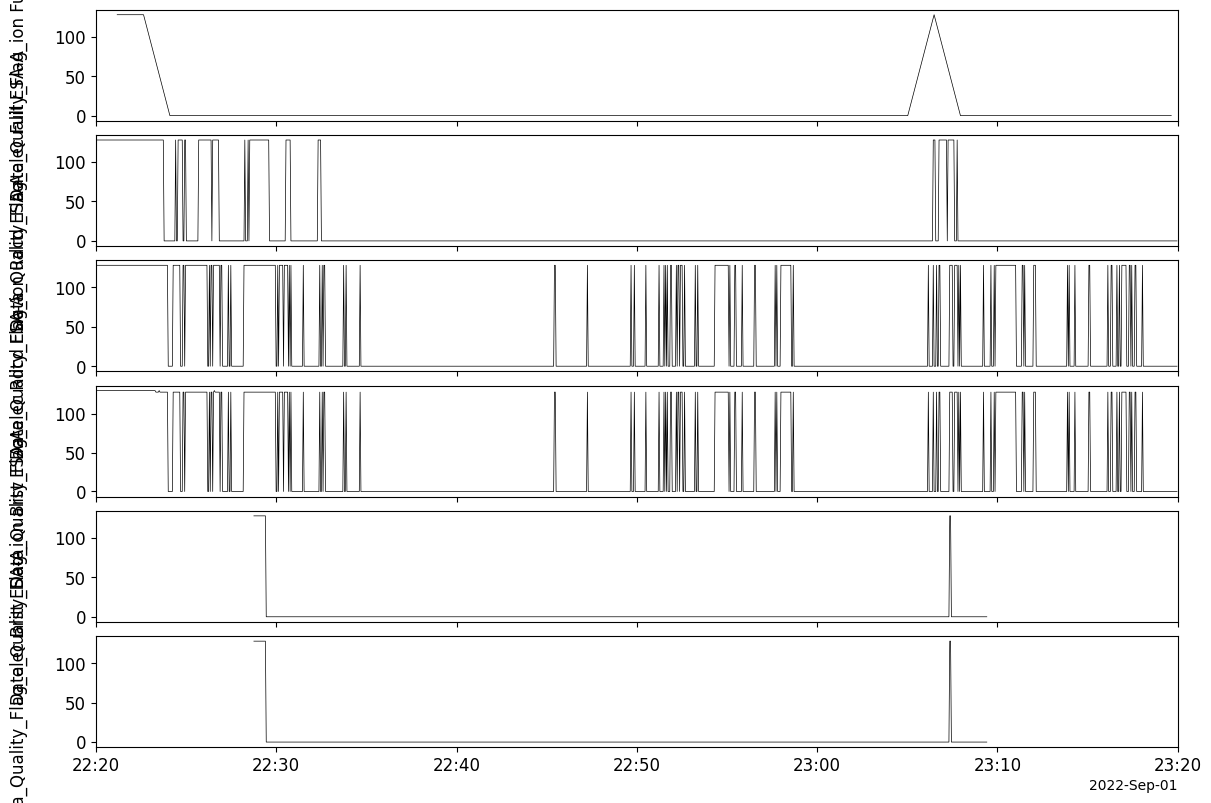

In [5]:
pt.tplot(['tha_peif_data_quality', 'tha_peef_data_quality', 'tha_peir_data_quality', 'tha_peer_data_quality', 'tha_peib_data_quality', 'tha_peeb_data_quality'])

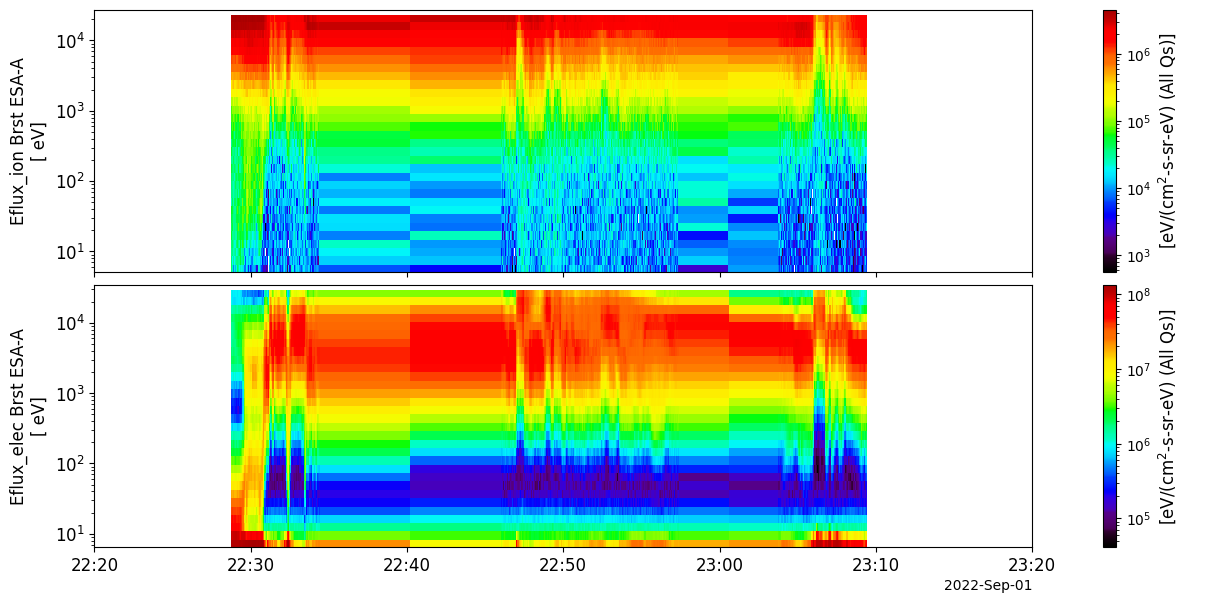

In [6]:
pt.tplot(['tha_peib_en_eflux', 'tha_peeb_en_eflux'])

In [ ]:
fgm_var = f'tha_fgl_gse' # GSE座標系のL2磁場データ
psp.themis.fgm(
    trange=time_range,
    probe='a',
    level='l2',
    varnames=[fgm_var]
)

# --- 3. dpcatを使ってPADを計算する ---
# dpcatは、(入力変数名, 出力変数名, 磁場変数名) のように指定する
electron_pad_var = f'tha_peeb_pad'
ion_pad_var = f'tha_peib_pad'

pt.dpcat('tha_peeb_flux', electron_pad_var, fgm_var)
pt.dpcat('tha_peib_flux', ion_pad_var, fgm_var)

# --- ロード＆作成された変数を確認 ---
print("作成されたtplot変数:")
print(pt.tplot_names())

# --- プロット ---
pt.timespan('2022-09-01/22:20:00', 1, keyword='hour')
pt.tplot([electron_pad_var, ion_pad_var, fgm_var])

05-Aug-25 17:36:05: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fgm/2022/
05-Aug-25 17:36:06: File is current: /mnt/j/observation_data//themis/tha/l2/fgm/2022/tha_l2_fgm_20220901_v01.cdf


AttributeError: module 'pytplot' has no attribute 'dpcat'